Reading scan data from: d:\eBATS\data\C0010\C0004R02_PARK25_AC_1D_SCAN.xlsx
Total scan cases: 180
Cases at T_air,in = 25.0 degC: 36


C:\Users\liu\AppData\Local\Temp\ipykernel_577920\517312830.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


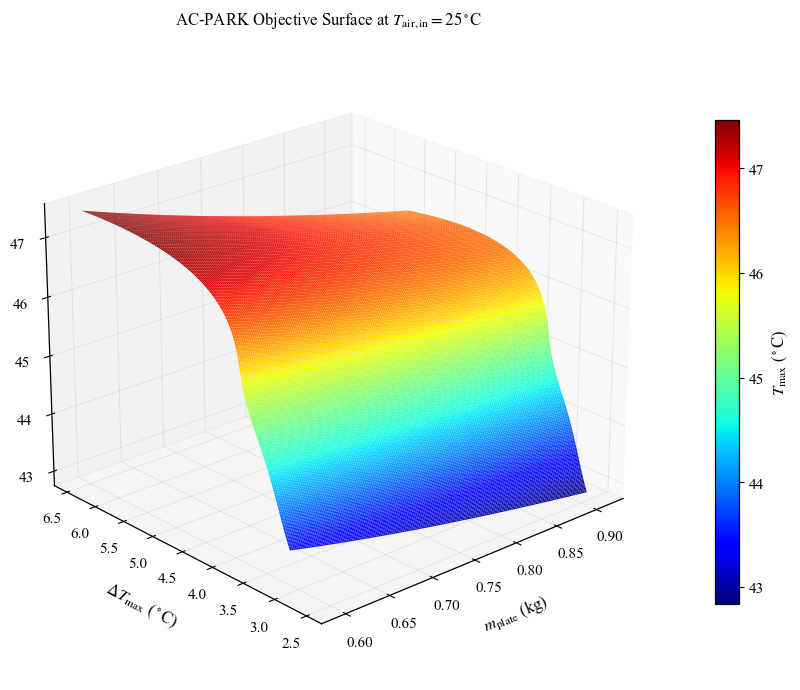


Saved PNG: d:\eBATS\out\C0010\C0010_PARK25_AC_surface_only_Xmass_YDeltaT_ZTmax.png
Saved PDF: d:\eBATS\out\C0010\C0010_PARK25_AC_surface_only_Xmass_YDeltaT_ZTmax.pdf


In [22]:
# ============================================================
# C0010 - AC-PARK Objective Surface Only
#
# Fixed condition:
#   T_air,in = 25 degC
#
# Objective-space axes:
#   X = m_plate
#   Y = DeltaTmax
#   Z = Tmax
#
# Surface color:
#   Tmax
#
# Plot style:
#   - smooth surface only
#   - no Pareto line
#   - no scatter points
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# ============================================================
# 1. File settings
# ============================================================

PROJECT_ROOT = os.path.abspath('../..')
CASE_ID = 'C0010'
SOURCE_FILE_NAME = 'C0004R02_PARK25_AC_1D_SCAN.xlsx'
file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, SOURCE_FILE_NAME)
output_dir = os.path.join(PROJECT_ROOT, 'out', CASE_ID)

if not os.path.exists(file_name):
    PROJECT_ROOT = r'D:\eBATS'
    file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, SOURCE_FILE_NAME)
    output_dir = os.path.join(PROJECT_ROOT, 'out', CASE_ID)

if not os.path.exists(file_name):
    file_name = os.path.join('/mnt/data', SOURCE_FILE_NAME)
    output_dir = os.path.join('/mnt/data', 'C0010_output')

if not os.path.exists(file_name):
    raise FileNotFoundError(f'Cannot find scan file: {file_name}')

os.makedirs(output_dir, exist_ok=True)

PNG_FILE = os.path.join(output_dir, 'C0010_PARK25_AC_surface_only_Xmass_YDeltaT_ZTmax.png')
PDF_FILE = os.path.join(output_dir, 'C0010_PARK25_AC_surface_only_Xmass_YDeltaT_ZTmax.pdf')

print(f'Reading scan data from: {file_name}')

# ============================================================
# 2. Read scan data
# ============================================================

data_all = pd.read_excel(file_name)
required_columns = ['case_id', 'V_air_m_s', 'T_air_in_C', 's_gap_mm', 'Tmax_mission_C', 'DeltaT_mission_max_C', 'm_bottom_plate_kg']
missing_columns = [column for column in required_columns if column not in data_all.columns]

if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

print(f'Total scan cases: {len(data_all)}')

# ============================================================
# 3. Fix inlet-air temperature at 25 degC
# ============================================================

T_air_normal = 25.0
data = data_all[np.isclose(data_all['T_air_in_C'], T_air_normal)].copy()

if len(data) == 0:
    raise ValueError(f'No cases found at T_air,in = {T_air_normal:.1f} degC.')

print(f'Cases at T_air,in = {T_air_normal:.1f} degC: {len(data)}')

# ============================================================
# 4. Build structured 6 x 6 grid
# ============================================================

velocity_values = np.sort(data['V_air_m_s'].unique())
gap_values = np.sort(data['s_gap_mm'].unique())

Tmax_grid = data.pivot(index='s_gap_mm', columns='V_air_m_s', values='Tmax_mission_C').reindex(index=gap_values, columns=velocity_values).to_numpy(dtype=float)
DeltaT_grid = data.pivot(index='s_gap_mm', columns='V_air_m_s', values='DeltaT_mission_max_C').reindex(index=gap_values, columns=velocity_values).to_numpy(dtype=float)
mass_grid = data.pivot(index='s_gap_mm', columns='V_air_m_s', values='m_bottom_plate_kg').reindex(index=gap_values, columns=velocity_values).to_numpy(dtype=float)

if np.isnan(Tmax_grid).any() or np.isnan(DeltaT_grid).any() or np.isnan(mass_grid).any():
    raise ValueError('The 36 design points do not form a complete structured grid.')

# ============================================================
# 5. Smooth interpolation
# ============================================================

v_dense = np.linspace(velocity_values.min(), velocity_values.max(), 160)
g_dense = np.linspace(gap_values.min(), gap_values.max(), 160)
V_dense, G_dense = np.meshgrid(v_dense, g_dense)

def interpolate_dense_surface(x_vals, y_vals, z_grid, x_dense, y_dense):
    try:
        from scipy.interpolate import RectBivariateSpline
        spline = RectBivariateSpline(y_vals, x_vals, z_grid, kx=3, ky=3)
        return spline(y_dense[:, 0], x_dense[0, :])
    except Exception:
        z_x = np.array([np.interp(x_dense[0, :], x_vals, row) for row in z_grid])
        return np.array([np.interp(y_dense[:, 0], y_vals, z_x[:, j]) for j in range(z_x.shape[1])]).T

Tmax_dense = interpolate_dense_surface(velocity_values, gap_values, Tmax_grid, V_dense, G_dense)
DeltaT_dense = interpolate_dense_surface(velocity_values, gap_values, DeltaT_grid, V_dense, G_dense)
mass_dense = interpolate_dense_surface(velocity_values, gap_values, mass_grid, V_dense, G_dense)

# ============================================================
# 6. Plot style
# ============================================================

font_size = 12
plt.rcdefaults()
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'stix', 'font.size': font_size, 'axes.labelsize': font_size, 'axes.titlesize': font_size, 'xtick.labelsize': font_size - 1, 'ytick.labelsize': font_size - 1, 'axes.linewidth': 0.9, 'axes.unicode_minus': False})

# ============================================================
# 7. Plot surface only
# ============================================================

fig = plt.figure(figsize=(8.8, 7.0))
ax = fig.add_subplot(111, projection='3d')

cmap = cm.get_cmap('jet')
norm = Normalize(vmin=np.nanmin(Tmax_dense), vmax=np.nanmax(Tmax_dense))
facecolors = cmap(norm(Tmax_dense))

ax.plot_surface(mass_dense, DeltaT_dense, Tmax_dense, facecolors=facecolors, rstride=1, cstride=1, linewidth=0.0, edgecolor='none', antialiased=True, shade=False, alpha=0.96)

ax.set_xlabel(r'$m_{\mathrm{plate}}$ (kg)', labelpad=10)
ax.set_ylabel(r'$\Delta T_{\max}$ ($^\circ$C)', labelpad=10)
ax.set_zlabel(r'$T_{\max}$ ($^\circ$C)', labelpad=10)
ax.set_title(r'AC-PARK Objective Surface at $T_{\mathrm{air,in}}=25^\circ$C', pad=14)

ax.view_init(elev=23, azim=-132)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo['grid']['linewidth'] = 0.6
    axis._axinfo['grid']['linestyle'] = '-'
    axis._axinfo['grid']['color'] = (0.75, 0.75, 0.75, 0.35)

mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, pad=0.08, shrink=0.76)
cbar.set_label(r'$T_{\max}$ ($^\circ$C)')

plt.tight_layout()
plt.savefig(PNG_FILE, dpi=600, bbox_inches='tight')
plt.savefig(PDF_FILE, dpi=600, bbox_inches='tight')
plt.show()

print()
print(f'Saved PNG: {PNG_FILE}')
print(f'Saved PDF: {PDF_FILE}')
